# Earthquake Damage Grade Prediction
---

The objective of this file to analyze perform Explanatory Data Analysis.


## Importing the Libraries
Let's import data.

In [5]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier,  HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
import warnings
import missingno as msno
import scipy.stats as stats
from scipy.stats import chi2_contingency
import keras
from keras.models import Sequential
from keras.models import Model
from keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout
# Instead of tensorflow.keras.wrappers.scikit_learn, use scikeras
from scikeras.wrappers import KerasClassifier # Changed import statement
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

## Getting the data
Let's load them into 2 dataframes: values and labels, and then let's combine in one dataframe, df.

In [8]:
values = pd.read_csv('train_values (2).csv')
labels = pd.read_csv('train_labels (2).csv')

df = pd.concat([values, labels['damage_grade']], axis=1)
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


## Exploratory Data Analysis (EDA)
Investigation of data


#### Data Shape
Number of rows and columns in the dataset

In [9]:
n_rows, n_cols = df.shape

print(f"this dataset has {n_rows} rows and {n_cols} columns")

this dataset has 260601 rows and 40 columns


#### Data Types
Data type of each column in the dataset

In [10]:
df.dtypes

,0
building_id,int64
geo_level_1_id,int64
geo_level_2_id,int64
geo_level_3_id,int64
count_floors_pre_eq,int64
age,int64
area_percentage,int64
height_percentage,int64
land_surface_condition,object
foundation_type,object


#### Summary Statistics
Summary statistics for the numerical variables

In [11]:
df.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


Same for categorical variables

In [12]:
df.describe(include='O')

,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,legal_ownership_status
count,260601,260601,260601,260601,260601,260601,260601,260601
unique,3,5,3,5,4,4,10,4
top,t,r,n,f,q,s,d,v
freq,216757,219196,182842,209619,165282,202090,250072,250939


#### Checking for Null values

In [13]:
print(df.isnull().sum())

building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       

**There is no null values inside of the dataset**

#### Checking for duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

**There are no duplicated rows**

#### Exploring the target variable
First, the distribution of target variable

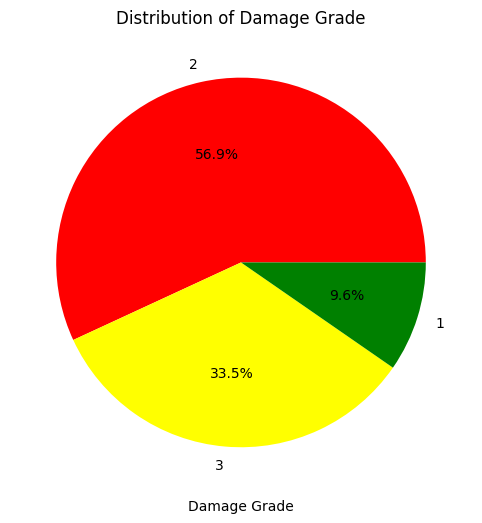

In [15]:
# Calculate the percentage of each class
class_counts = df['damage_grade'].value_counts(normalize=True) * 100

# Visualize the distribution
plt.figure(figsize=(8, 6))
ax = class_counts.plot(kind='pie', autopct='%1.1f%%', colors=['red', 'yellow', 'green'])
plt.xlabel('Damage Grade')
plt.ylabel('')

plt.title('Distribution of Damage Grade')

plt.show()

**There is an imbalance in the dataset as each category.**

#### Studying Correlations
Study correlations between our features and the target variable.

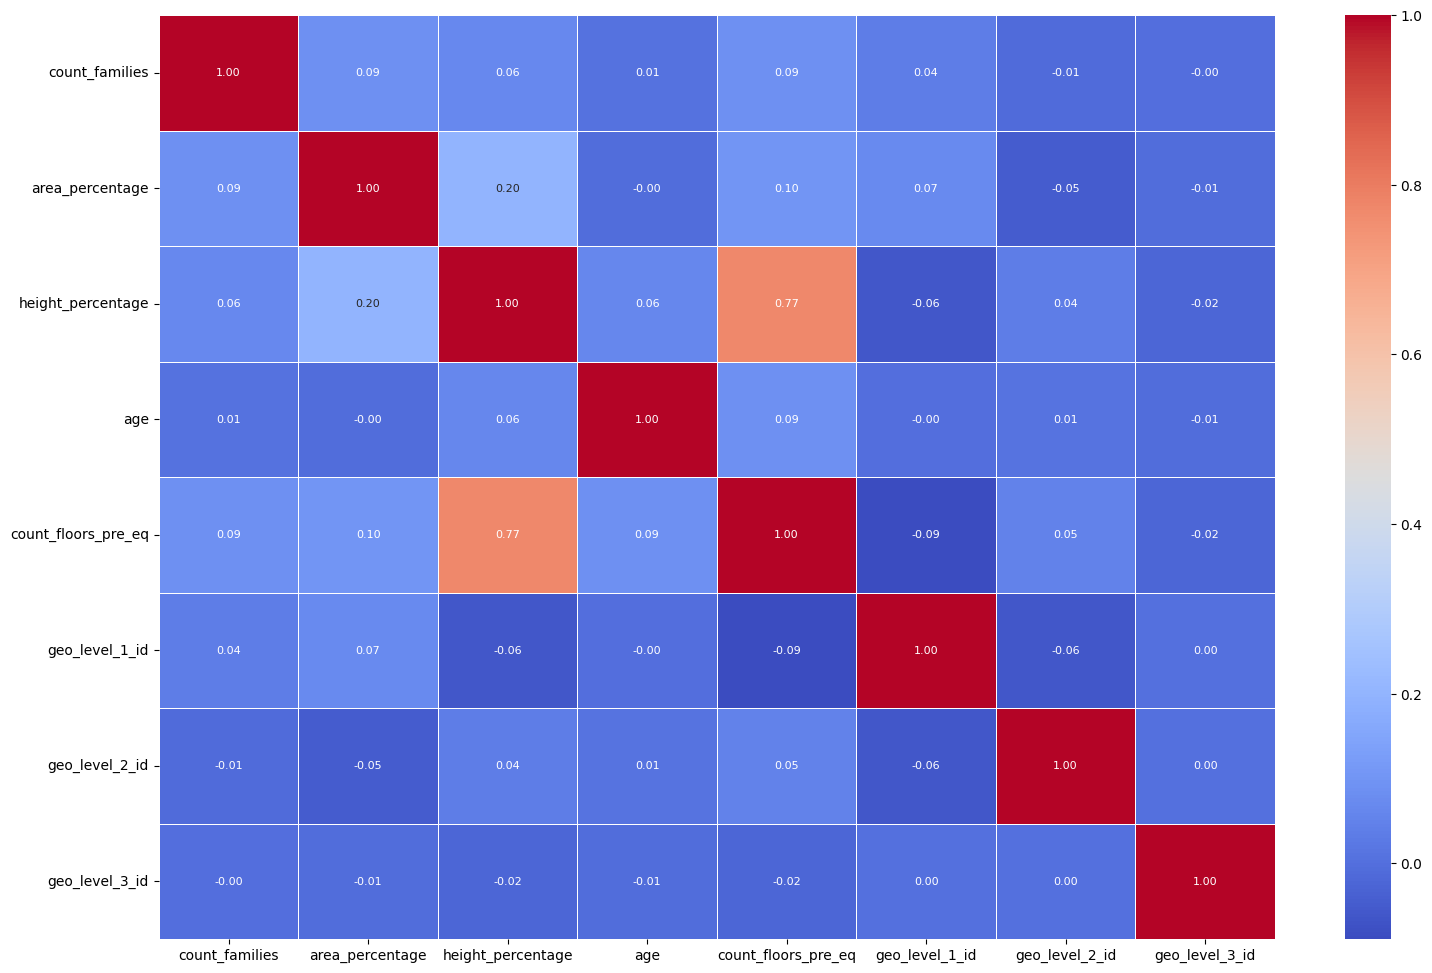

In [17]:
# Compute correlation matrix
num_vars = ['count_families', 'area_percentage', 'height_percentage', 'age', 'count_floors_pre_eq', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id']
# Convert selected columns to numeric, errors='coerce' will replace non-numeric values with NaN
numeric_df = df[num_vars].apply(pd.to_numeric, errors='coerce')

corr_matrix = numeric_df.corr()

# Set figure size
fig, ax = plt.subplots(figsize=(18, 12))

# Plot correlation matrix using a heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5, ax=ax, annot_kws={"fontsize":8})
plt.show()

This is the numerical correlation analysis. The area, the number of floors, and some superstructure features are correlated with the target.

##### Numerical Features

inorder to see if a variable is correlated with a categorical variable, distribution with respect to each category is plotted. If the distributions are the same, then there is no correlation.

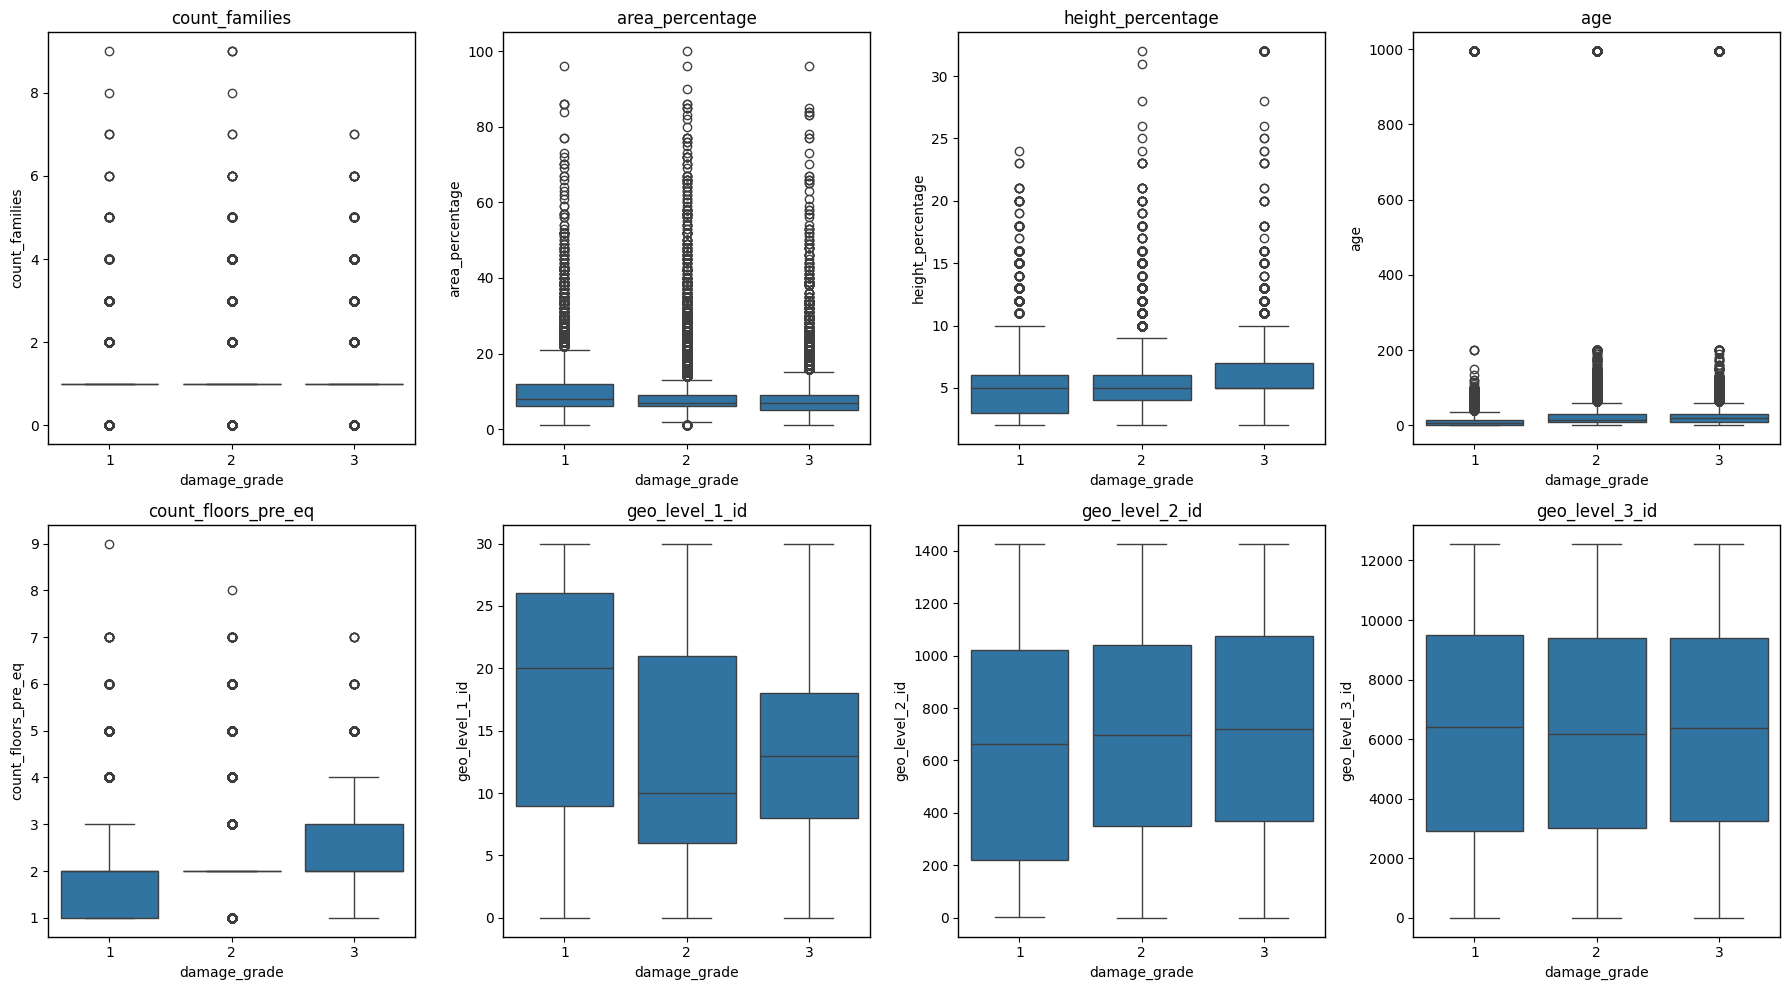

In [25]:
num_vars = ['count_families', 'area_percentage', 'height_percentage', 'age', 'count_floors_pre_eq', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id']
target_var = 'damage_grade'

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(18, 10))

for i, num_var in enumerate(num_vars):
    row = i // 4  # Calculate the row index
    col = i % 4   # Calculate the column index

    ax = sns.boxplot(x=target_var, y=num_var, data=df, ax=axs[row, col])
    ax.set_title(num_var)
    ax.set_facecolor('none')

    # Draw a frame around the subplot
    ax.spines['left'].set_linewidth(1)
    ax.spines['right'].set_linewidth(1)
    ax.spines['top'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['bottom'].set_color('black')

plt.tight_layout()
plt.show()

##### Categorical Features
This dataset contains many categorical features. FGrouping the features in 3 groups helps visualize in each cell one group of features

**We define a helper function to plot subplots, and we use it for each group instead of repeating the same code.**

In [19]:
def plot_correlation_cat_features(num_rows, num_cols, binary_vars, target_var):
  # Create the plot grid and initialize the subplot index
  fig, axs = plt.subplots(num_rows, num_cols, figsize=(30, 10))
  subplot_index = 0

  # Loop over the binary variables and create a stacked bar chart for each one in a separate subplot
  for binary_var in binary_vars:
      if subplot_index >= num_rows * num_cols:
          break
      row = subplot_index // num_cols
      col = subplot_index % num_cols
      ax = axs[row, col]

      # Calculate the count and percentage of each class
      class_counts = df.groupby([binary_var, target_var])[target_var].count().unstack()
      class_percentages = class_counts.div(class_counts.sum(axis=1), axis=0)

      # Plot the stacked bar chart with percentage labels
      class_percentages.plot(kind='bar', stacked=True, ax=ax)
      #ax.set_title(binary_var)
      ax.set_ylabel('Percentage')

      # Add percentage labels to the bars
      for p in ax.patches:
          width = p.get_width()
          height = p.get_height()
          x, y = p.get_xy()
          ax.annotate(f'{height:.1%}', (x + width / 2, y + height / 2), ha='center', va='center', fontsize=8)

      # Move the legend to the right side of the plot
      ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

      subplot_index += 1

  # Adjust the spacing between subplots and display the plot
  plt.subplots_adjust(hspace=0.5, wspace=0.6)
  plt.show()

##### Superstructure Features
Let's examine if the superstructure features are correlated or not with the target variable.

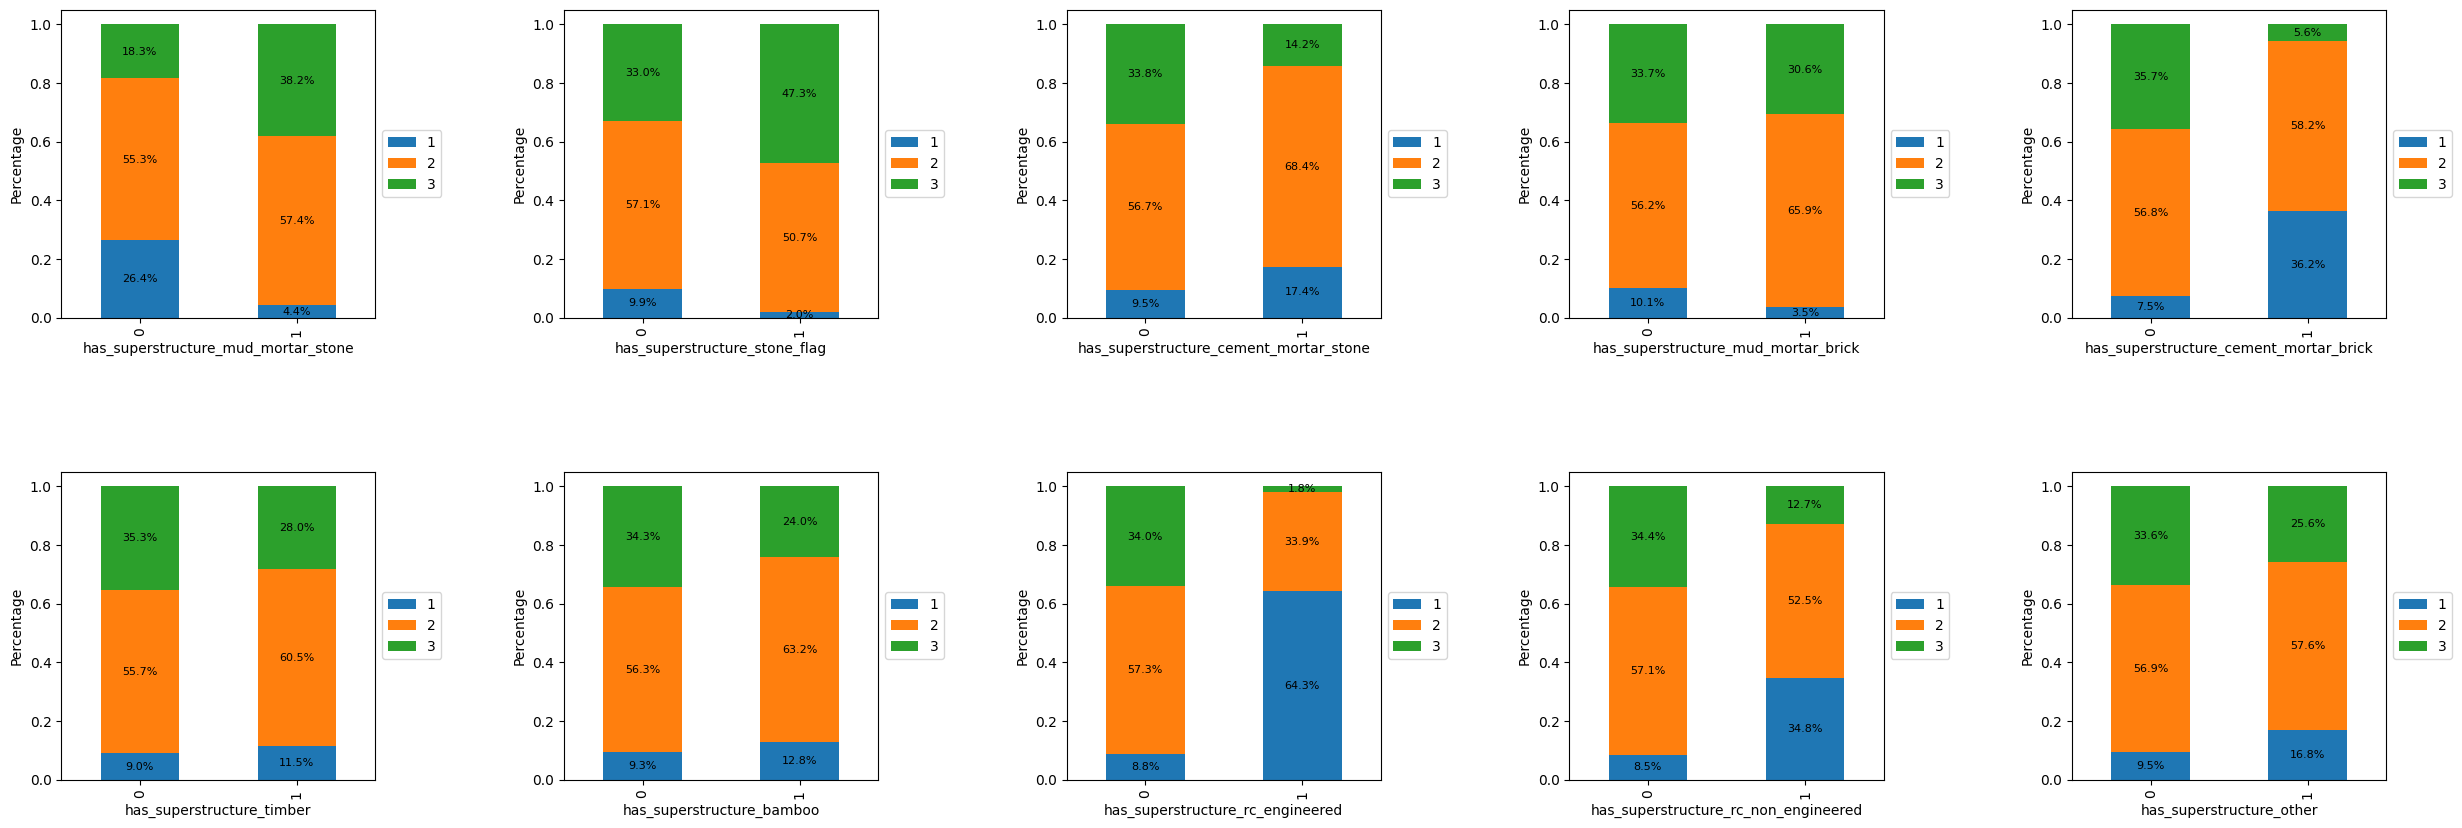

In [20]:
binary_vars = ['has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone',
               'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
               'has_superstructure_bamboo', 'has_superstructure_rc_engineered', 'has_superstructure_rc_non_engineered', 'has_superstructure_other']
target_var = 'damage_grade'

# Set the number of rows and columns for the plot grid
num_rows = 2
num_cols = 5

plot_correlation_cat_features(num_rows, num_cols, binary_vars, target_var)

**From the above charts, the percentages are really different, indicating a potential relationship between the superstructure variables and the target variable**

##### Secondary User Features
let's see if the secondary use features are correlated or not with the target variable.

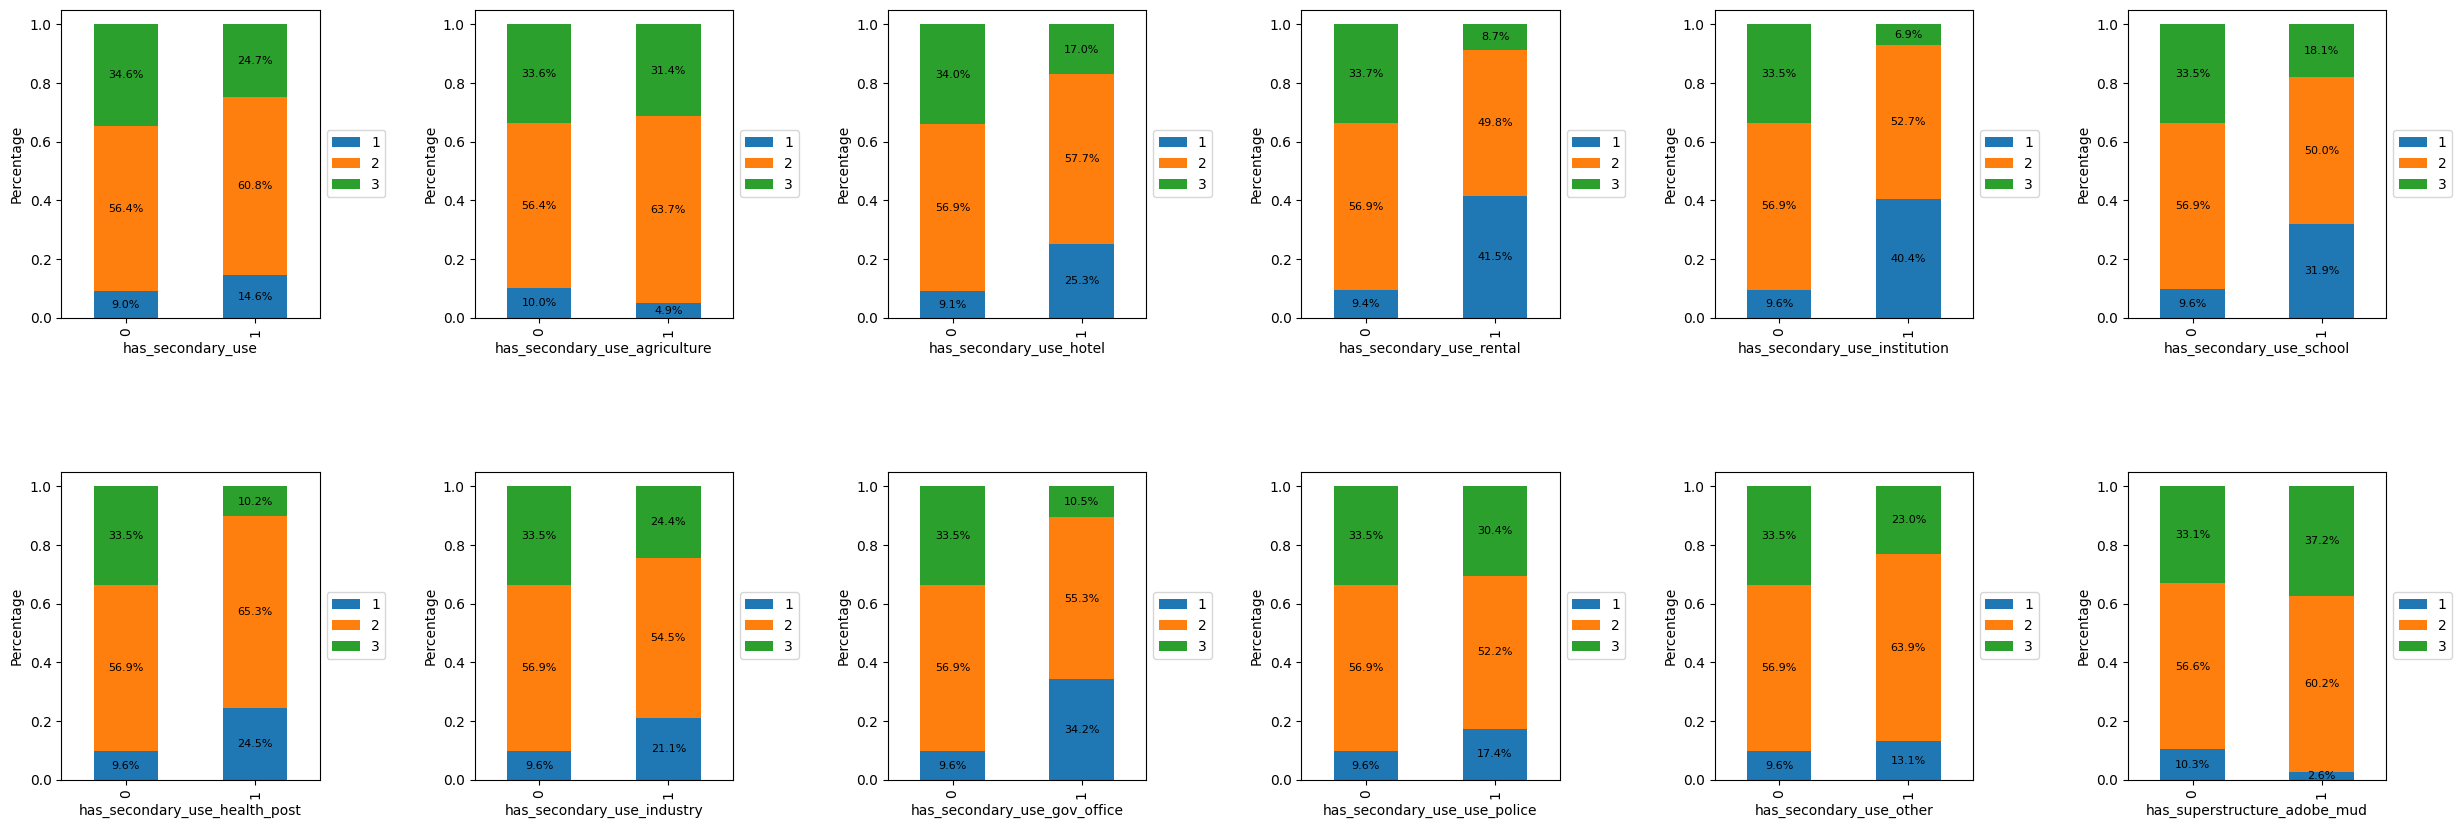

In [21]:
binary_vars = ['has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel',
               'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school',
               'has_secondary_use_health_post', 'has_secondary_use_industry', 'has_secondary_use_gov_office',
               'has_secondary_use_use_police','has_secondary_use_other','has_superstructure_adobe_mud']
target_var = 'damage_grade'

# Set the number of rows and columns for the plot grid
num_rows = 2
num_cols = 6

plot_correlation_cat_features(num_rows, num_cols, binary_vars, target_var)

**These features are also correlated with the target variable.**

##### Remaining Categorical Features
Let's perform same with other variables

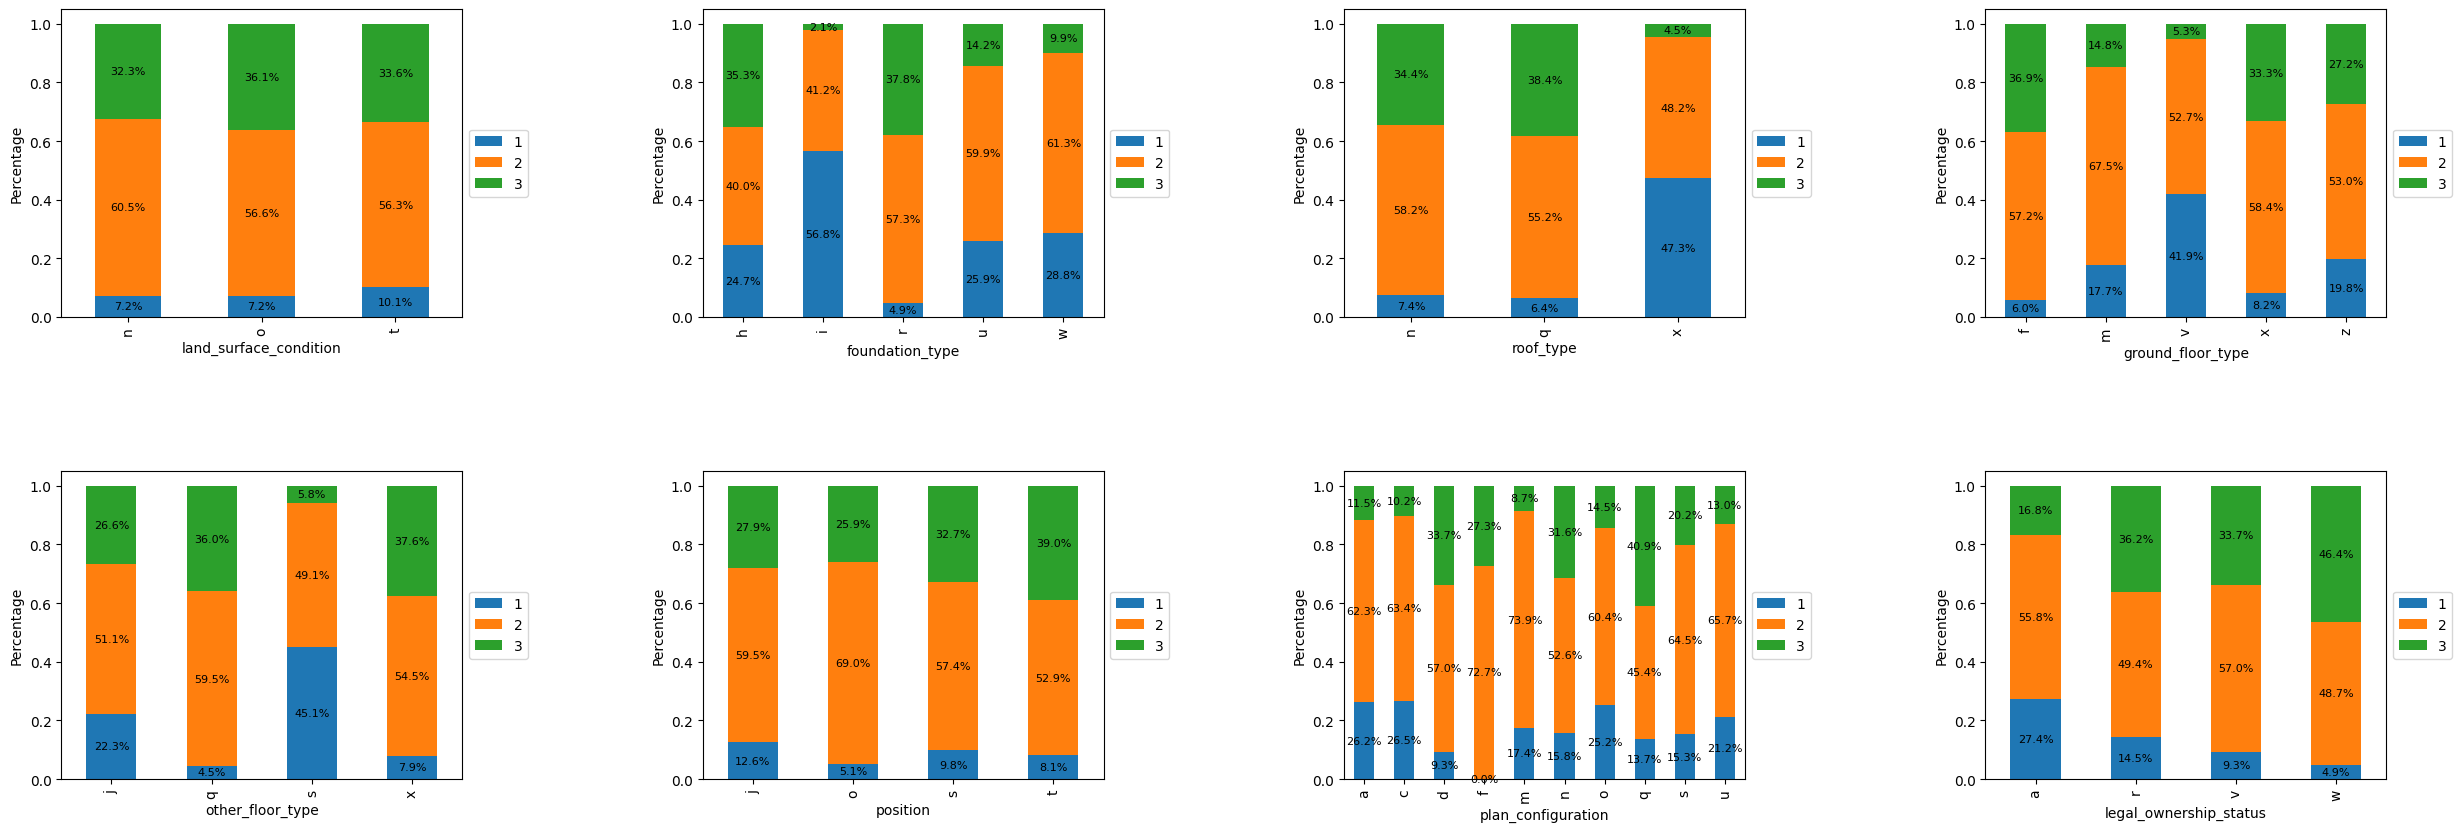

In [22]:
categorical_vars = ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type',
                    'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
target_var='damage_grade'

# Set the number of rows and columns for the plot grid
num_rows = 2
num_cols = 4

plot_correlation_cat_features(num_rows, num_cols, categorical_vars, target_var)

**The land_surface_condition seems to be the least correlated with the target.**